# Logistic Regression: Binary

<h2 style="color:green" align="center">
    Would a person buy life insurance based on  one variable (age) using logistic regression
</h2>

This is binary logistic regression problem as there are only two possible outcomes (person buys insurance or doesn't). 

In [32]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Data collection

In [33]:

data = {
    "age": [
        22, 25, 47, 52, 46, 56, 55, 60, 62, 61,
        18, 28, 27, 29, 49, 55, 25, 58, 19, 18,
        21, 26, 40, 45, 50, 54, 23, 27, 25, 19,
        42, 44, 68, 30, 68
    ],
    
    "bought_insurance": [
        0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
        0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
        0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
        1, 1, 1, 0, 1
    ]
}

df = pd.DataFrame(data)

print(df)

    age  bought_insurance
0    22                 0
1    25                 0
2    47                 1
3    52                 0
4    46                 1
5    56                 1
6    55                 0
7    60                 1
8    62                 1
9    61                 1
10   18                 0
11   28                 0
12   27                 0
13   29                 0
14   49                 1
15   55                 1
16   25                 1
17   58                 1
18   19                 0
19   18                 0
20   21                 0
21   26                 0
22   40                 1
23   45                 1
24   50                 1
25   54                 1
26   23                 0
27   27                 0
28   25                 0
29   19                 0
30   42                 1
31   44                 1
32   68                 1
33   30                 0
34   68                 1


## EDA

In [34]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               35 non-null     int64
 1   bought_insurance  35 non-null     int64
dtypes: int64(2)
memory usage: 692.0 bytes
None


In [35]:
print(df.describe())

             age  bought_insurance
count  35.000000         35.000000
mean   39.828571          0.514286
std    16.243525          0.507093
min    18.000000          0.000000
25%    25.000000          0.000000
50%    42.000000          1.000000
75%    54.500000          1.000000
max    68.000000          1.000000


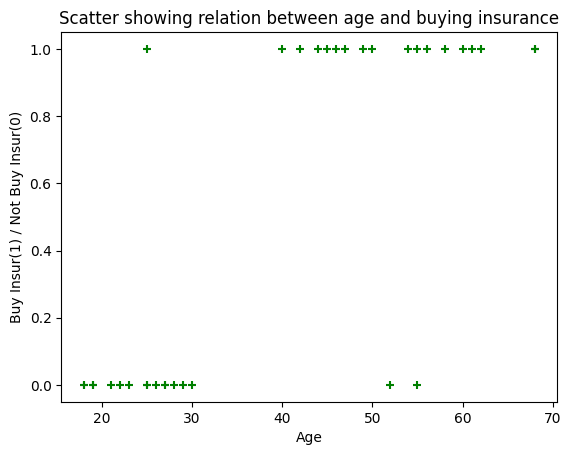

In [36]:
# Lets see how many people buy insurance based on age
plt.scatter(df['age'],
            df['bought_insurance'],
            marker='+', 
            color='green'
)

# Labels and title
plt.xlabel("Age")
plt.ylabel("Buy Insur(1) / Not Buy Insur(0)")
plt.title("Scatter showing relation between age and buying insurance")
plt.show()

### Observation: Generally people over 40 buy insurance and younger people do not.
It follows a sigmoid function curve.

## Split data into train and test

In [37]:
from sklearn.model_selection import train_test_split
X = df[['age']] # feature space: independant variable
y = df['bought_insurance'] # dependant variable, Label/Reponse variable

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [38]:
# I want to see the shape of my training/testing dataset
print(X_train.shape)
print(X_test.shape)

(28, 1)
(7, 1)


So 21 records are for training and 6 for testing. Not a huge dataset, but it would show proof of concept.

In [39]:
# Now I want to see the testing dataset: feature space
print(X_test)

    age
26   23
13   29
24   50
21   26
15   55
29   19
19   18


# Model training

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression() # This is modelling

In [41]:
model.fit(X_train, y_train) # This line of code would train your model

LogisticRegression()

## Model Evaluation
Lets make a prediction on one data point. Then we see how the model performs on the test dataset

In [42]:
# Lets see if s/o of age=25 would buy insurance
age = 25
age_2Darray = np.array([[age]])  # Convert to 2D array

prediction = model.predict_proba(age_2Darray)
print(prediction) # 1st number is prob of not buying, 2nd number is prob of buying


probability = prediction[0, 1]  # Probability of buying insurance
print(f"Probability of buying insurance for age {age}: {probability}")

predicted_value = model.predict(age_2Darray)
print(f"Prediction for a {age}-year-old: {predicted_value[0]}")

[[0.84755852 0.15244148]]
Probability of buying insurance for age 25: 0.1524414794385959
Prediction for a 25-year-old: 0


In [43]:
print(X_test)
print("#############")
print(y_test)

    age
26   23
13   29
24   50
21   26
15   55
29   19
19   18
#############
26    0
13    0
24    1
21    0
15    1
29    0
19    0
Name: bought_insurance, dtype: int64


In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(f"y predicted: {y_pred}")

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

y predicted: [0 0 1 0 1 0 0]
Accuracy: 1.0


In [45]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         2

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



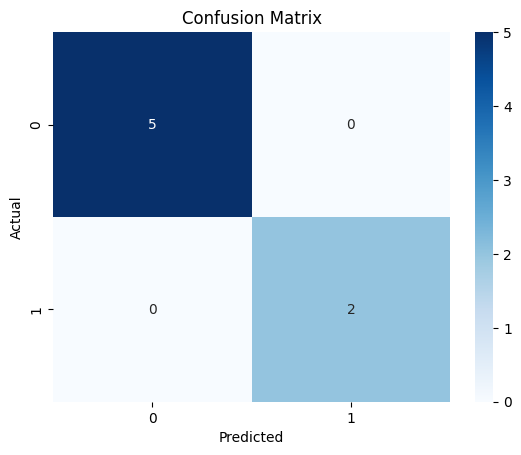

In [46]:
# I want to see the confusion matrix: The diagonal elements should be high number.
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Lets put the actual value and predicted values next to each other so we can see it better

In [47]:
# Create a dataFrame to compare actual with predicted values for better visualization 
comparison_df = pd.DataFrame({
    'Actual'   : y_test, 
    'Predicted': y_pred}
)

print(comparison_df)

    Actual  Predicted
26       0          0
13       0          0
24       1          1
21       0          0
15       1          1
29       0          0
19       0          0


In [48]:
# show me the prediction probability of test dataset
print(model.predict_proba(X_test)) # 1st value is the probab of class 0, 2nd value is prob of class 1

[[0.87908048 0.12091952]
 [0.76481019 0.23518981]
 [0.16293194 0.83706806]
 [0.82941586 0.17058414]
 [0.09054462 0.90945538]
 [0.92553864 0.07446136]
 [0.93426826 0.06573174]]


### Above, 1st number is the prob of it being 0, and the 2nd number is prob of it being 1.

## Sigmoid curve
Lets generate sigmoid curve.

age_range: [18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68.]
probabilities: [0.06573174 0.07446136 0.08424578 0.09518368 0.10737518 0.12091952
 0.13591221 0.15244148 0.17058414 0.19040096 0.21193167 0.23518981
 0.26015777 0.28678244 0.31497187 0.34459343 0.37547384 0.4074014
 0.44013055 0.47338862 0.50688454 0.54031876 0.57339396 0.60582546
 0.63735079 0.69678956 0.72434993 0.75030292 0.77457283 0.79712163
 0.81794507 0.83706806 0.85453959 0.87042762 0.88481418 0.89779096
 0.90945538 0.91990738 0.92924672 0.93757093 0.94497379 0.95154418
 0.95736543 0.96251489 0.96706379 0.97107726 0.9746145  0.97772906
 0.98046915 0.98287802]


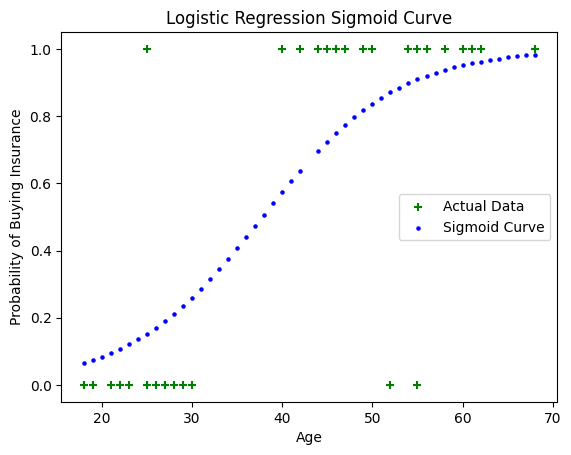

In [49]:
# Generate smooth age values for the sigmoid curve
age_range = np.linspace(df['age'].min(), df['age'].max(), 50).reshape(-1, 1)# create 50 ages
age_range = np.round(age_range,0)
print(f"age_range: {age_range.flatten()}")


# Predict probabilities of above artificially generated ages using the trained model
probabilities = model.predict_proba(age_range)[:, 1]  # Probability of class 1, i.e. buying insurance
print(f"probabilities: {probabilities}") 

# Plot the scatter plot
plt.scatter(df['age'], df['bought_insurance'], marker='+', color='green', label="Actual Data")

# Plot the sigmoid curve(probability curve)
plt.scatter(age_range, probabilities, color='blue', s=5, label="Sigmoid Curve")

# Labels and title
plt.xlabel("Age")
plt.ylabel("Probability of Buying Insurance")
plt.title("Logistic Regression Sigmoid Curve")
plt.legend()
plt.show()


### Lets calculate the if a 25 year old person is going to buy insur ? 

In [50]:
age = 25
age = 25
age_2Darray = np.array([[age]])  # Convert to 2D array

prediction = model.predict_proba(age_2Darray)
print(prediction) # 1st number is prob of not buying, 2nd number is prob of buying


probability = prediction[0, 1]  # Probability of buying insurance
print(f"Probability of buying insurance for age {age}:     {probability}")
print(f"Probability of NOT buying insurance for age {age}: {1 - probability}")

predicted_value = model.predict(age_2Darray)
print(f"Prediction for a {age}-year-old: {predicted_value[0]}")

[[0.84755852 0.15244148]]
Probability of buying insurance for age 25:     0.1524414794385959
Probability of NOT buying insurance for age 25: 0.8475585205614041
Prediction for a 25-year-old: 0


He would NOT buy insurance because his probability of not buying is 0.84

The image referenced contains the classic logistic (sigmoid) function transformed for a single predictor variable ($X$). The mathematical relationship between the probability $p(X)$ and the coefficients $\beta_0$ and $\beta_1$ is written as:


$$p(X) = \frac{e^{\beta_0 + \beta_1 X}}{1 + e^{\beta_0 + \beta_1 X}} = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X)}}$$ 


- $p(X)$ is the probability that X belongs to a category
- $\beta_0$ and $\beta_1$ are the values that are found by logisticregression method above.

In [51]:
b0 = model.intercept_
b1 = model.coef_
print(b0)
print(b1)

[-5.06773102]
[[0.13408608]]


In [52]:
import math
def logistic_function(z):
  return math.exp(z) / (1 + math.exp(z))


z = b0 + b1 * age
y = logistic_function(z)
print(f"prob of NOT buying: {1-y}") 
print(f"prob of     buying: {y}") 

prob of NOT buying: 0.8475585205614041
prob of     buying: 0.1524414794385959


### Good . This value matches with above.